In [1]:
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [ ]:
# reference arxiv : 1610.09713 [gr-qc]

In [18]:
# function to extract data from bbh simulations

def get_simulation_data(filepath):
    
    with open(filepath, 'r') as file:
        lines = file.readlines()
        
    init_line = [line for line in lines if line.startswith("# Initial Conditions")][0]
    
    q_match = re.search(r'q=([0-9.]+)', init_line)
    chi1_match = re.search(r'χ1=([0-9.]+)', init_line)
    chi2_match = re.search(r'χ2=([0-9.]+)', init_line)
    
    q = float(q_match.group(1)) if q_match else 1.0
    chi1_mag = float(chi1_match.group(1)) if chi1_match else 0.0
    chi2_mag = float(chi2_match.group(1)) if chi2_match else 0.0
    
    print(f"Extracted initial conditions: q={q}, chi1={chi1_mag}, chi2={chi2_mag}")

    df = pd.read_csv(filepath, comment='#')
    
    theta1 = df['theta1_rad'].values
    theta2 = df['theta2_rad'].values
    time_steps = df['time_M'].values
    orbital_separation = df['separation_M'].values
    
    chi1_parallel = chi1_mag * np.cos(theta1)
    chi2_parallel = chi2_mag * np.cos(theta2)
    
    return {
        'time': time_steps,
        'q': q,
        'chi1_parallel': chi1_parallel,
        'chi2_parallel': chi2_parallel,
        'chi1_mag': chi1_mag,
        'chi2_mag': chi2_mag,
        'a' : orbital_separation
    }

In [19]:
# function to calculate remnant final mass using Healy-Lousto polynomials

def healy_final_mass(q, chi1_parallel, chi2_parallel, M_tot=1.0):
    
    eta = q / (1.0 + q)**2
    S_par = chi1_parallel + chi2_parallel
    Delta_par = chi1_parallel - chi2_parallel
    
    # Non-spinning term
    e0 = 0.04827
    e1 = 0.01707
    
    # Spin-Orbit term 
    f0 = 0.01191
    f1 = 0.02762
    g0 = -0.00755
    g1 = 0.01804
    
    # Spin-Spin term 
    h0 = 0.00485
    h1 = 0.02325
    i0 = 0.00346
    i1 = 0.01160
    j0 = -0.00161
    j1 = -0.01323

    E0_term = eta * (e0 + e1 * eta)
    
    ESO_term = (eta * S_par * (f0 + f1 * eta)) + \
               (eta * Delta_par * (g0 + g1 * eta))
               
    ESS_term = (eta * (S_par**2) * (h0 + h1 * eta)) + \
               (eta * (Delta_par**2) * (i0 + i1 * eta)) + \
               (eta * S_par * Delta_par * (j0 + j1 * eta))
               
    E_rad = E0_term + ESO_term + ESS_term
    
    Mf_array = M_tot * (1.0 - E_rad)
    
    return Mf_array

In [ ]:
# function to calculate remnant final spin using Healy-Lousto polynomials

def healy_final_spin(q, chi1_par, chi2_par):
    
    eta = q / (1.0 + q)**2
    m1 = q / (1.0 + q)
    m2 = 1.0 / (1.0 + q)

    t0, t1, t2, t3 = -2.8904, -0.2181, 3.328, 3.205
    
    S_sum = chi1_par + chi2_par
    l_isco = 2.0 * np.sqrt(3.0) + t0 * eta + t1 * eta**2 + \
             t2 * S_sum * eta + \
             t3 * (S_sum**2) * eta

    L_orb = l_isco * eta

    S_int = (m1**2 * chi1_par) + (m2**2 * chi2_par)

    a_f = S_int + L_orb

    a_f_clipped = np.minimum(np.abs(a_f), 0.999999)
    
    return a_f_clipped

In [44]:
def calculate_remnant_entropy(Mf, af):

    area = 8 * np.pi * (Mf**2) * (1 + np.sqrt(1 - af**2))
    entropy = area / 4
    return entropy

In [38]:
# example using a simulation from bbh_simulation_archive

filepath = "/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q:0.40_χ1:0.50_χ2:0.50_θ1:45_θ2:45_ΔΦ:90.csv"

data = get_simulation_data(filepath) 

time_array = data['time']
mass_ratio = data['q']
chi1_par = data['chi1_parallel']
chi2_par = data['chi2_parallel']
separation_array = data['a']

Mf_array = healy_final_mass(mass_ratio, chi1_par, chi2_par, M_tot=1.0)
Sf_array = healy_final_spin(mass_ratio, chi1_par, chi2_par)
Entropy_array = calculate_remnant_entropy(Mf_array, Sf_array)

Extracted initial conditions: q=0.4, chi1=0.5, chi2=0.5


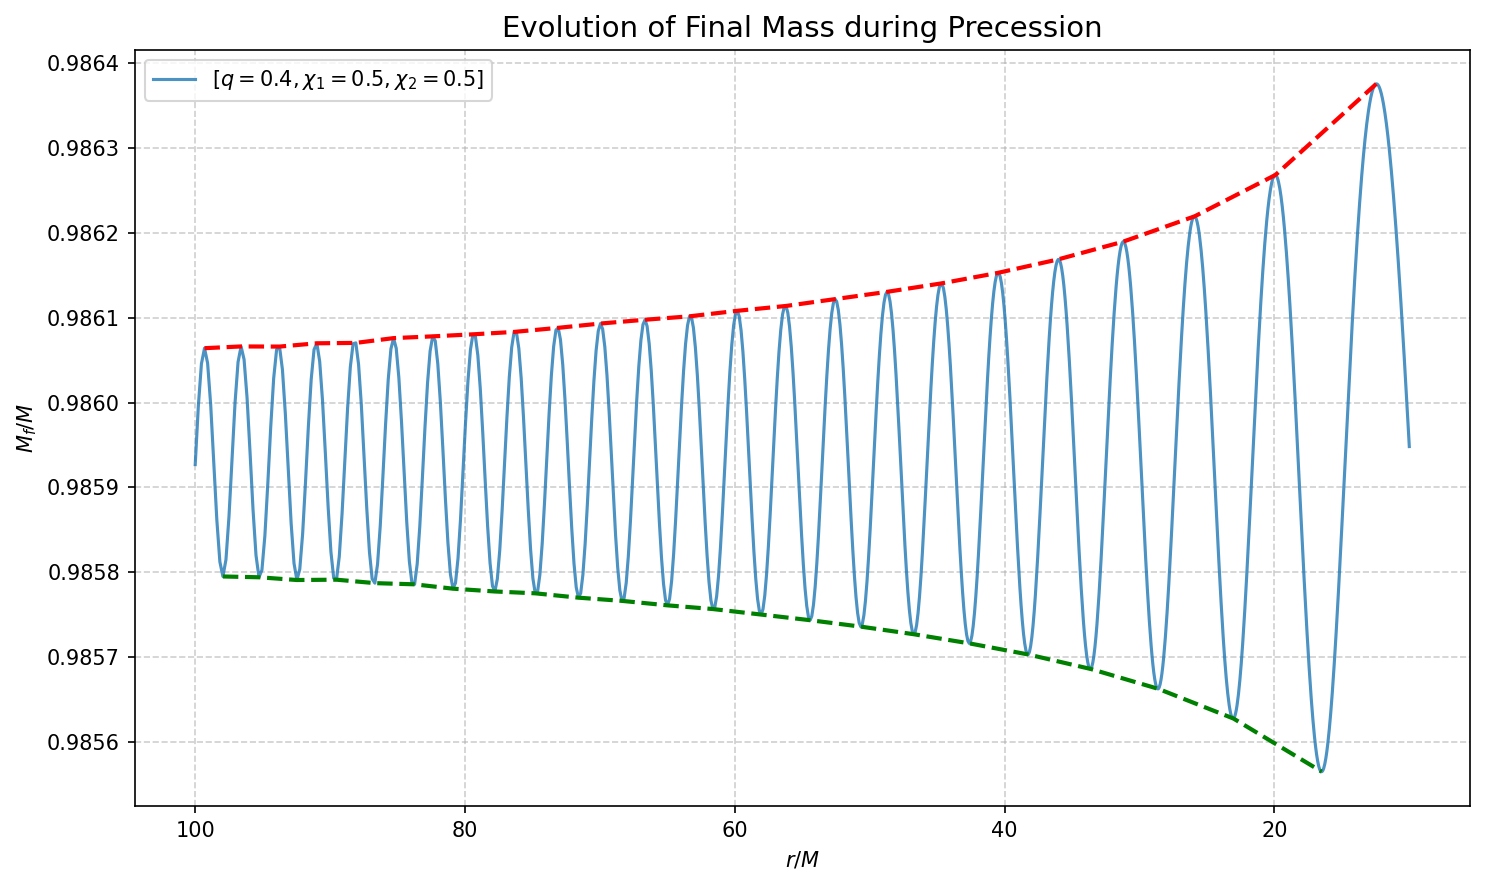

In [21]:
# graph of final mass evolution

mass_ratio = data['q']
chi1_mag = data['chi1_mag']
chi2_mag = data['chi2_mag']

plt.figure(figsize=(10, 6), dpi=150)

params_label = f'[$q={mass_ratio}, \\chi_1={chi1_mag}, \\chi_2={chi2_mag}$]'

plt.plot(separation_array, Mf_array, color='#1f77b4', linewidth=1.5, alpha=0.8, label=params_label)

upper_peaks, _ = find_peaks(Mf_array, distance=5)
lower_peaks, _ = find_peaks(-Mf_array, distance=5)

if len(upper_peaks) > 0 and len(lower_peaks) > 0:
    plt.plot(separation_array[upper_peaks], Mf_array[upper_peaks], color='red', 
             linestyle='--', linewidth=2)
    plt.plot(separation_array[lower_peaks], Mf_array[lower_peaks], color='green', 
             linestyle='--', linewidth=2)

plt.title('Evolution of Final Mass during Precession', fontsize=14)
plt.xlabel(r'$r/M$', fontsize=10)
plt.ylabel(r'$M_f / M$', fontsize=10)
plt.gca().invert_xaxis()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

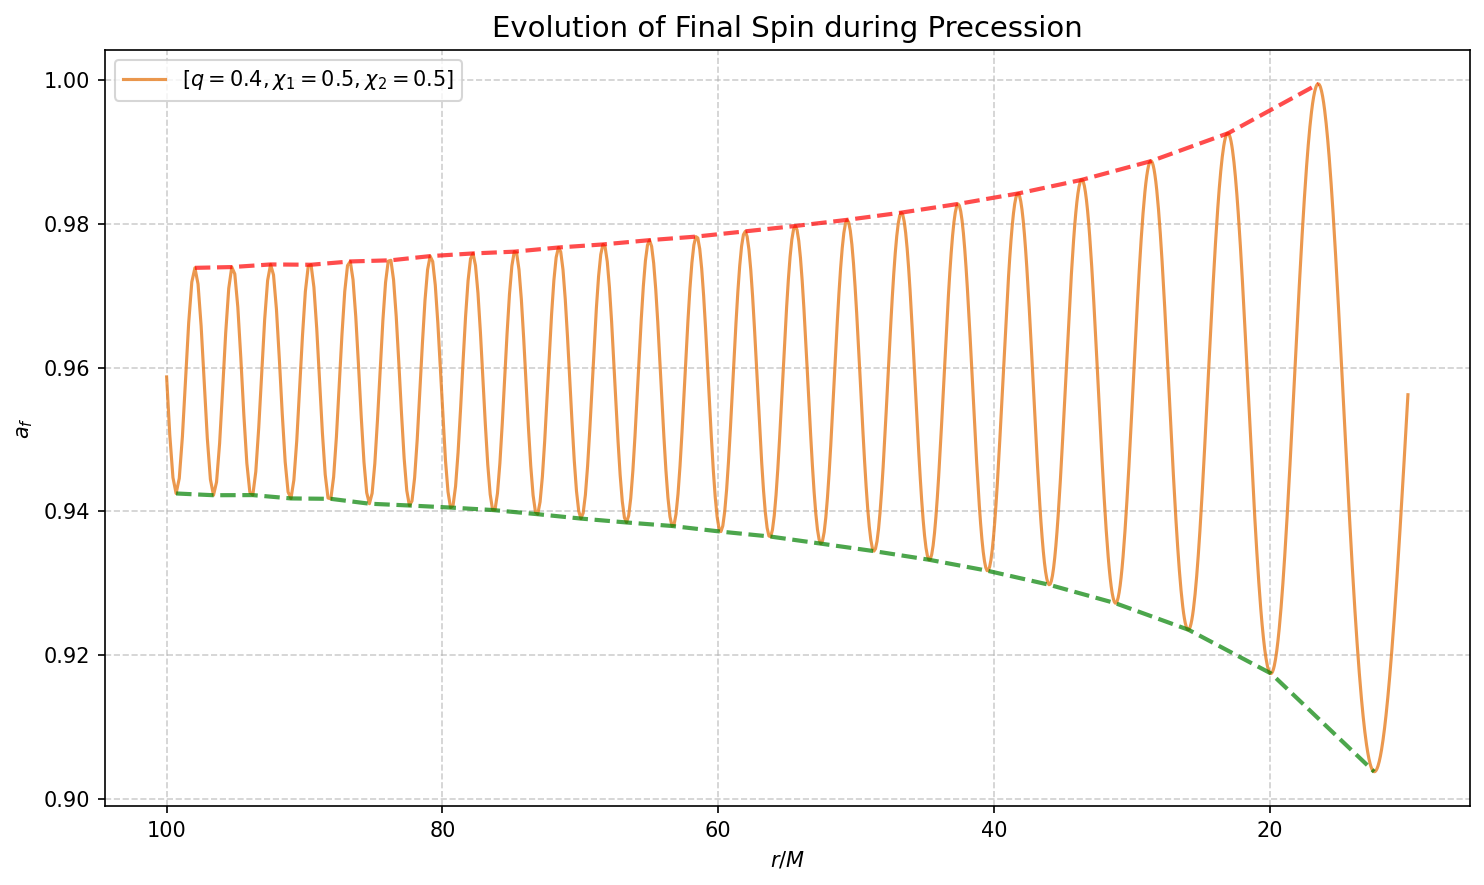

In [42]:
# graph of final spin evolution

mass_ratio = data['q']
chi1_mag = data['chi1_mag']
chi2_mag = data['chi2_mag']

af_array = healy_final_spin(mass_ratio, data['chi1_parallel'], data['chi2_parallel'])


plt.figure(figsize=(10, 6), dpi=150)
params_label = f'[$q={mass_ratio}, \\chi_1={chi1_mag}, \\chi_2={chi2_mag}$]'
plt.plot(separation_array, af_array, color='#e67e22', linewidth=1.5, alpha=0.8, label=params_label)


upper_peaks_af, _ = find_peaks(af_array, distance=5)
lower_peaks_af, _ = find_peaks(-af_array, distance=5)

if len(upper_peaks_af) > 0 and len(lower_peaks_af) > 0:
    plt.plot(separation_array[upper_peaks_af], af_array[upper_peaks_af], color='red', 
             linestyle='--', linewidth=2, alpha=0.7)
    plt.plot(separation_array[lower_peaks_af], af_array[lower_peaks_af], color='green', 
             linestyle='--', linewidth=2, alpha=0.7)

plt.title('Evolution of Final Spin during Precession', fontsize=14)
plt.xlabel(r'$r/M$', fontsize=10)
plt.ylabel(r'$a_f$', fontsize=10)
plt.gca().invert_xaxis() 
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

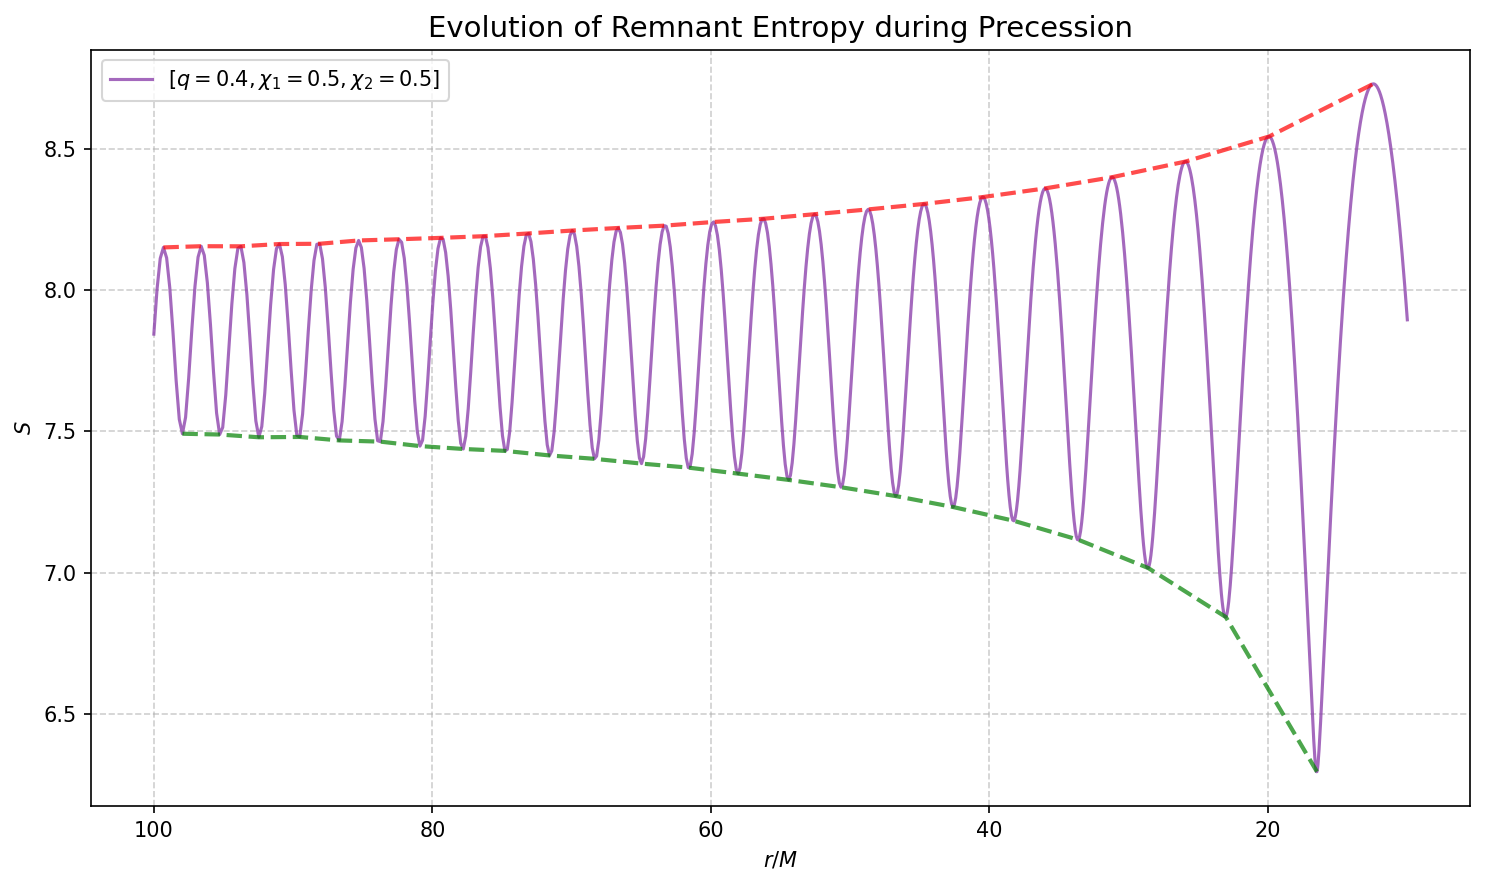

In [43]:
# graph of entropy evolution

mass_ratio = data['q']
chi1_mag = data['chi1_mag']
chi2_mag = data['chi2_mag']

Entropy_array = calculate_remnant_entropy(Mf_array, af_array)

plt.figure(figsize=(10, 6), dpi=150)
params_label = f'[$q={mass_ratio}, \\chi_1={chi1_mag}, \\chi_2={chi2_mag}$]'

plt.plot(separation_array, Entropy_array, color='#8e44ad', linewidth=1.5, alpha=0.8, label=params_label)

upper_peaks_s, _ = find_peaks(Entropy_array, distance=5)
lower_peaks_s, _ = find_peaks(-Entropy_array, distance=5)

if len(upper_peaks_s) > 0 and len(lower_peaks_s) > 0:
    plt.plot(separation_array[upper_peaks_s], Entropy_array[upper_peaks_s], color='red', 
             linestyle='--', linewidth=2, alpha=0.7)
    plt.plot(separation_array[lower_peaks_s], Entropy_array[lower_peaks_s], color='green', 
             linestyle='--', linewidth=2, alpha=0.7)

plt.title('Evolution of Remnant Entropy during Precession', fontsize=14)
plt.xlabel(r'$r/M$', fontsize=10)
plt.ylabel(r'$S$', fontsize=10)
plt.gca().invert_xaxis() 
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

In [6]:
# analysis of Precession Frequency using FFT

num_windows = 15
window_size = len(Mf_array) // num_windows

f_precession_evolution = []
avg_separation_evolution = []
time_centers = []

for i in range(num_windows):

    start = i * window_size
    end = (i + 1) * window_size

    t_win = data['time'][start:end]
    mf_win = Mf_array[start:end]
    sep_win = data['a'][start:end]
    
    sig_win = mf_win - np.mean(mf_win)
    n_win = len(t_win)
    dt_win = np.mean(np.diff(t_win))
    
    psd_win = np.abs(np.fft.rfft(sig_win))**2
    freqs_win = np.fft.rfftfreq(n_win, d=dt_win)
    
    peak_idx = np.argmax(psd_win[1:]) + 1
    
    f_precession_evolution.append(freqs_win[peak_idx])
    avg_separation_evolution.append(np.mean(sep_win))
    time_centers.append(np.mean(t_win))

print("frequency analysis completed")

frequency analysis completed


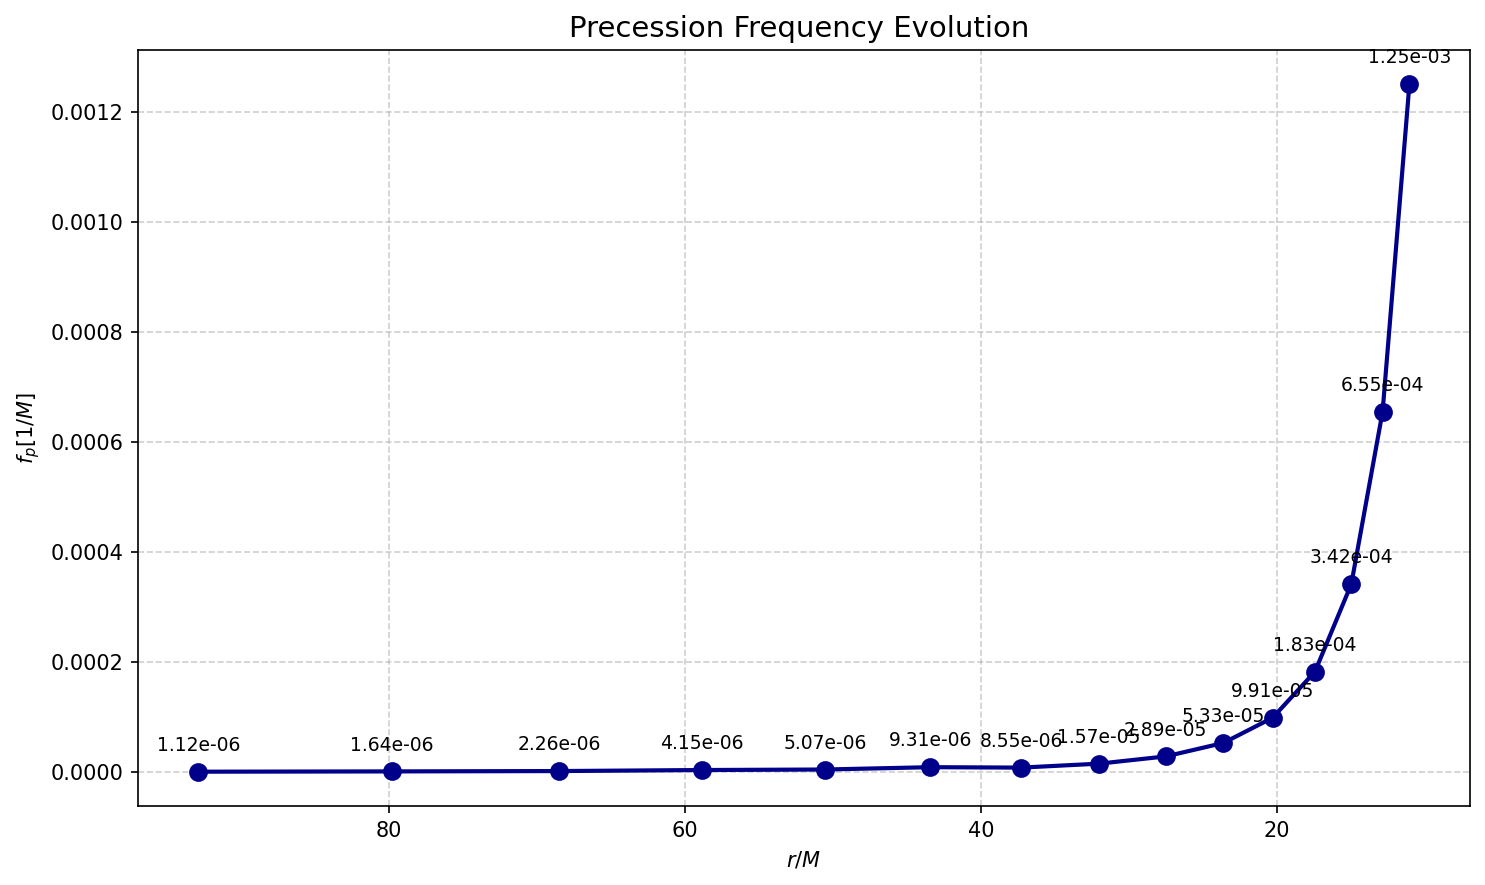

In [7]:
# graph of Precession Frequency evolution

plt.figure(figsize=(10, 6), dpi=150)

plt.plot(avg_separation_evolution, f_precession_evolution, 'o-', 
         color='darkblue', linewidth=2, markersize=8)

plt.gca().invert_xaxis()

for i, val in enumerate(f_precession_evolution):
    plt.annotate(f"{val:.2e}", (avg_separation_evolution[i], f_precession_evolution[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title("Precession Frequency Evolution ", fontsize=14)
plt.xlabel(r"$r/M$", fontsize=10)
plt.ylabel(r"$f_p [1/M]$", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

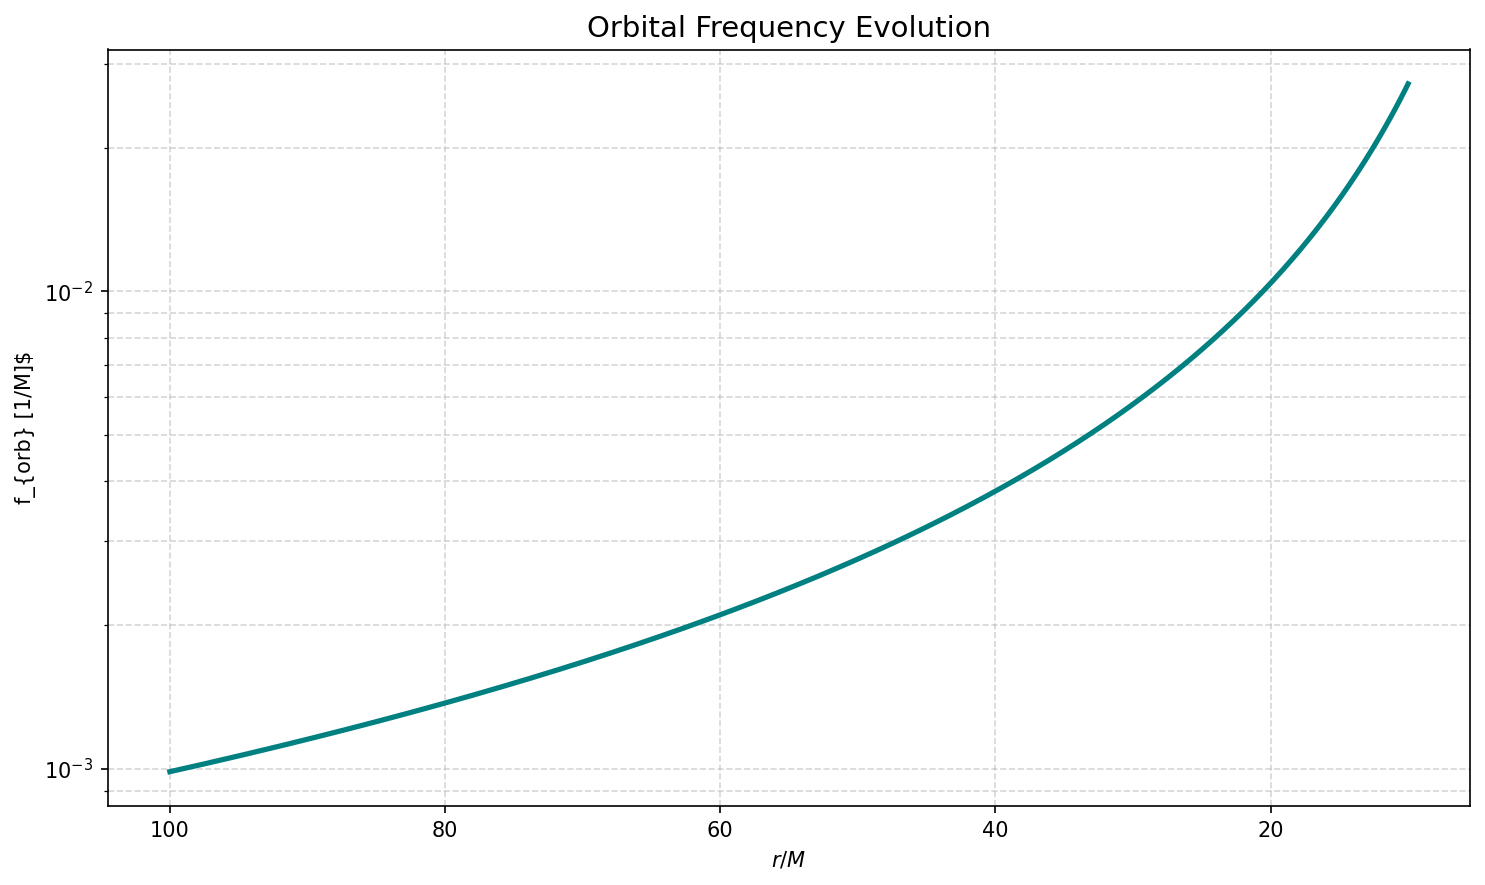

In [8]:
# analysis of orbital frequency

time_array = data['time']
radius_array = data['a']
q = data['q']
eta = q / (1 + q)**2 

omega_kepler = radius_array**(-1.5)
omega_1pn = omega_kepler * (1 + (eta - 3) / (2 * radius_array))


plt.figure(figsize=(10, 6), dpi=150)
plt.plot(radius_array, omega_1pn, color='teal', linewidth=2.5)

plt.gca().invert_xaxis() 
plt.yscale('log')
plt.title("Orbital Frequency Evolution", fontsize=14)
plt.xlabel(r"$r/M$", fontsize=10)
plt.ylabel(r"f_{orb} [1/M]$", fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()